<a href="https://colab.research.google.com/github/DonAtharva/Ad-sales-Simple-Linear-Regression/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('sales.xlsx', header=None)

In [3]:
df.shape

(36, 2)

In [4]:
df.head()

,0,1
0,12.0,15
1,20.5,16
2,21.0,18
3,15.5,27
4,15.3,21


In [5]:
df.columns = ['Sales','Advertising']

In [6]:
df.head()

,Sales,Advertising
0,12.0,15
1,20.5,16
2,21.0,18
3,15.5,27
4,15.3,21


In [7]:
df.describe()

,Sales,Advertising
count,36.000000,36.000000
mean,24.255556,28.527778
std,6.185118,18.777625
min,12.000000,1.000000
25%,20.300000,15.750000
50%,24.250000,23.000000
75%,28.600000,41.000000
max,36.500000,65.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        36 non-null     float64
 1   Advertising  36 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 708.0 bytes


#Assigning values and Scatter Plot

In [9]:
X = df['Sales'].values
y = df['Advertising'].values

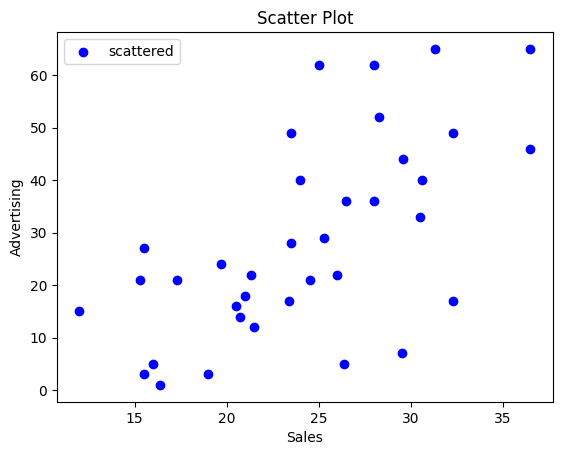

In [10]:
plt.scatter(X,y, color='blue', label='scattered')
plt.title('Scatter Plot')
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.legend()
plt.show()

#Reshape

In [11]:
X=X.reshape(-1,1)
y=y.reshape(-1,1)

In [12]:
print(X.shape)
print(y.shape)

(36, 1)
(36, 1)


#Model Mechanics

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24, 1)
(12, 1)
(24, 1)
(12, 1)


In [15]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)

#Model Slope and Intercept

In [19]:
a = lm.coef_
b = lm.intercept_
print("estimated slope",a)
print("estimated intercept",b)

estimated slope [[1.60509347]]
estimated intercept [-11.16003616]


In [32]:
# So, our fitted regression line is

# y = 1.60509347 * x - 11.16003616

# That is our linear model.

#Prediction

In [30]:
lm.predict(X)[0:5]
#first five values

array([[ 8.10108551],
       [21.74438002],
       [22.54692675],
       [13.71891266],
       [13.39789396]])

In [31]:
print((lm.predict([[24]])))
#indivisual value

[[27.36220717]]


#RMSE (Root Mean Square Error)

In [39]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)
print("RMSE value = {:.4f}".format(rmse))

RMSE value = 11.2273


#R2 Score

In [41]:
from sklearn.metrics import r2_score
meow = r2_score(y_test,y_pred)
print("R2 score value {:.4f}".format(meow))

R2 score value 0.5789


#Conclusion

The RMSE value has been found to be 11.2273. It means the standard deviation for our prediction is 11.2273. So, sometimes we expect the predictions to be off by more than 11.2273 and other times we expect less than 11.2273. So, the model is not good fit to the data.

In business decisions, the benchmark for the R2 score value is 0.7. It means if R2 score value >= 0.7, then the model is good enough to deploy on unseen data whereas if R2 score value < 0.7, then the model is not good enough to deploy. Our R2 score value has been found to be .5789. It means that this model explains 57.89 % of the variance in our dependent variable. So, the R2 score value confirms that the model is not good enough to deploy because it does not provide good fit to the data.

<function matplotlib.pyplot.show(close=None, block=None)>

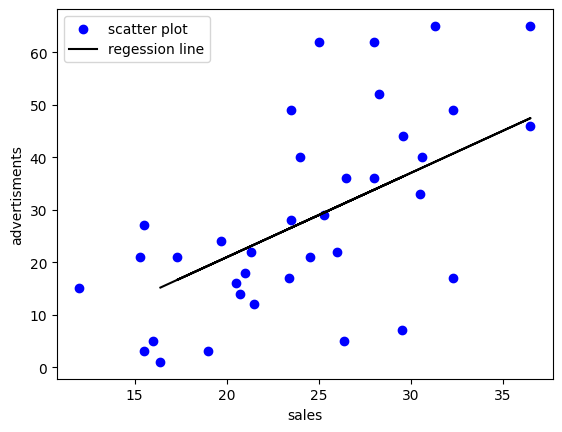

In [46]:
plt.scatter(X ,y , color="blue", label="scatter plot")
plt.plot(X_test,y_pred, color="black" , label="regession line")
plt.xlabel("sales")
plt.ylabel("advertisments")
plt.legend()
plt.show

#Residual Analysis

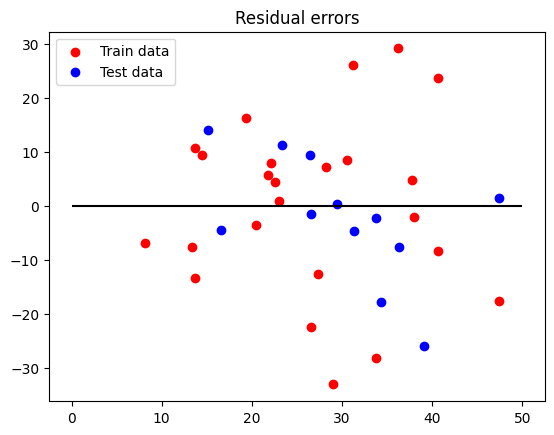

In [50]:
plt.scatter(lm.predict(X_train), lm.predict(X_train) - y_train, color = 'red', label = 'Train data')
plt.scatter(lm.predict(X_test), lm.predict(X_test) - y_test, color = 'blue', label = 'Test data')
plt.hlines(xmin = 0, xmax = 50, y = 0,color="black")
plt.title('Residual errors')
plt.legend()
plt.show()

#Overfitting and Underfitting

In [53]:
print("Training set score: {:.4f}".format(lm.score(X_train,y_train)))
print("Test set score: {:.4f}".format(lm.score(X_test,y_test)))

Training set score: 0.2861
Test set score: 0.5789


Test data should be 10% more accurate than training data always.
But in some cases 2% is also accepted (usually very big data)

The model does not learn the relationships appropriately from the training data. Thus, the model performs poorly on the training data. It is a clear sign of Underfitting. Hence, I validated my finding that the linear regression model does not provide good fit to the data.

Underfitting means our model performs poorly on the training data. It means the model does not capture the relationships between the training data. This problem can be improved by increasing model complexity. We should use more powerful models like Polynomial regression to increase model complexity.